# December 3, 2025
### This is a notebook to perform MCA on 251030_JANP-132_LT

In [1]:
from sklearn.decomposition import PCA
import prince
import mca

import sys, common, pickle, collections, math, numpy, scipy.stats
from pyx import *
from icecream import ic
import pandas as pd
from Bio import SeqIO
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

## Functions

In [64]:
def parsePickleFile(pickleFile, barcodeDict=None):
    """
    dataDict is of format:
    {readID:{edit_string,barcode,query_string,ref_string,aligned_pairs:...}}
    Will sort reads according to barcode, and output a tally of the number
    of reads per barcode. Will also compute the total size (in nts) of each
    barcode, to get a sense of coverage.
    
    Will output a dictionary of format:
    {bc:{readID:{position:edit}}}
    """
    ##start by unpickling the input file
    with open(pickleFile,'rb') as f:
        dataDict=pickle.load(f)
    ##
    aa=collections.defaultdict(lambda:collections.defaultdict(int))
    for readID,subDict in dataDict.items():
        bc=subDict['barcode']
        if barcodeDict is not None:
            if bc not in barcodeDict:
                continue
        queryLength=len(subDict['read_sequence'])
        aa[bc]['ct']+=1
        aa[bc]['length']+=queryLength
    ##
    for k,v in aa.items():
        print('Barcode %s had %s sequences totaling %s kilo nts.'%(\
            k,v['ct'],v['length']/1000))
    ##
    bb=collections.defaultdict(lambda:collections.defaultdict(dict))
    ##
    for readID,subDict in dataDict.items():
        barCode=subDict['barcode']
        #print(barCode,readID)
        editString=subDict['edit_string']
        #print(editString,len(editString))
        readSeq=subDict['read_sequence_aligned']
        #print(readSeq,len(readSeq))
        refSeq=subDict['ref_sequence_aligned']
        #print(refSeq,len(refSeq))
        alignedPairs=subDict['aligned_pairs']
        #print(alignedPairs,len(alignedPairs))
        #sys.exit()
        if barcodeDict is not None:
            if barCode not in barcodeDict:
                continue
        for ii in range(len(alignedPairs)-1):
            entry=alignedPairs[ii]
            idx=entry[0]
            absIdx=entry[1]
            if idx!=None and absIdx!=None:
                seq=refSeq[ii]
                edit=editString[ii]
                if seq=='A' and edit!='2' and absIdx<=704:
                    ##695 is where the RT primer binds--anything past this
                    ##is artifact.
                    bb[barCode][readID][absIdx]=int(edit)
    ##
    return bb

def parseBarcodeFile(barcodeFile):
    '''
    Given a barcode txt file, will return a dict of
    {barcode:library_name}
    '''
    bcDict={}
    with open(barcodeFile,'r') as f:
        for line in f:
            line=line.rstrip()
            print(line)
            if line=='':
                continue
            parts=line.split(',')
            bc=parts[0]
            libName=parts[1]
            bcDict[bc]=libName
    ##
    return bcDict

def formatForMCA(dataDict,numReads,minEditFreq,maxEditFreq):
    """
    dataDict={bc:{readID:{position:1/0}}}
    numReads is an integer.
    minEditFreq is a frequency (e.g., 0.7)
    maxEditFreq is a frequency (e.g., 1.0)
    Will sort each bc's readIDs by longest -> shortest, and then select the
    numReads longest reads with at least minEditFreq of 1's
    Will then convert to a list-of-lists like:
    [[0,1,1,0,...,1],
     [1,1,0,1,...,1],
     ...
     [1,0,0,0,...,0]]
     where each row represents a different readID. Will also return a list
     of bcs, which are the row labels.
    """
    aa=[]
    ##This part just gets the numReads reads from each bc
    for bc,readDict in dataDict.items():
        temp=[]
        for readID,positDict in readDict.items():
            if sum(positDict.values())/len(positDict)>=minEditFreq and \
               sum(positDict.values())/len(positDict)<=maxEditFreq:
                temp.append(len(positDict))
        ##
        temp.sort()
        temp.reverse()
        ##
        temp2=[]
        for readID,positDict in readDict.items():
            if len(positDict) in temp[:numReads]:
                if sum(positDict.values())/len(positDict)>=minEditFreq:
                    # temp2.append((bc,positDict))
                    temp2.append((bc,readID,positDict))
            if len(temp2)==numReads:
                break
        ##
        aa+=temp2
    ##
    ##now get all the positions
    positions=[]
    for entry in aa:
        for k in entry[2]: ##entry[2] is the positDict
            positions.append(k)
    ##now get unique positions, and then sort them
    positions=list(set(positions))
    positions.sort()
    ##now prepare outputs
    matrixOfEdits=[]
    listOfBCs=[]
    listOfReadIDs=[]
    for entry in aa:
        ##record the bc
        listOfBCs.append(entry[0])
        ##record the readID
        listOfReadIDs.append(entry[1])
        ##now convert the dict to a vector/list
        temp=[]
        for k in positions:
            # cluster on lysine window [220, 380]
            if k in entry[2]: ##entry[2] is the positDict
                if k >= 220 and k <= 380:
                    v=entry[2][k]
                else:
                    v=numpy.nan##in case no value
            else:
                v=numpy.nan##in case no value
            temp.append(v)
        ##
        matrixOfEdits.append(temp)
    ##
    return matrixOfEdits,listOfBCs,listOfReadIDs

def doMCAandPlot(matrixOfEdits,listOfBCs,listOfReadIDs,outPrefix):
    """
    matrixOfEdits is a list of lists, where each list is a list of 1/0/nan
    indicated edit status. listOfBCs are the labels associated with that.
    Will run MCA and plot the first two components.
    """
    ##convert to DF
    X = pd.DataFrame(matrixOfEdits,\
        columns=['A%s'%(ii) for ii in range(len(matrixOfEdits[0]))])
    ##initialize mca
    mca = prince.MCA(n_components=5, n_iter=5, \
        copy=True, check_input=True, engine='sklearn', \
        random_state=42, correction="greenacre")
    ##
    mca_fit = mca.fit(X)
    X_mca = mca_fit.transform(X)
    ##create labels, but don't actually attached them to the DF
    labels = pd.Series(listOfBCs, name='label')
    readID_labels = pd.Series(listOfReadIDs, name='readID')
    ##add the labels
    X_mca['label'] = labels.values
    X_mca['readID'] = readID_labels.values
    ##print some results
    print(mca.eigenvalues_summary)
    print(mca.column_coordinates(X))
    ##
    for ii in range(4):
        ##plot the data
        fig, ax = plt.subplots(figsize=(6, 6))
        for label in X_mca['label'].unique():
            subset = X_mca[X_mca['label'] == label]
            ax.scatter(subset[ii], subset[ii+1], label=label)
        ##set axis labels
        ax.set_title('MCA of Binary Vectors')
        ax.set_xlabel('MCA Dimension %s'%(ii+1))##+1 b/c python 0-based
        ax.set_ylabel('MCA Dimension %s'%(ii+2))
        ax.legend()
        ##save output
        plt.savefig('%s.%s.%s.png'%(outPrefix,ii,ii+1))
        plt.show()
        plt.close()
    # plot heatmap of column contributions
    contributions = mca.column_contributions_
    print(contributions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(contributions, cmap='viridis')
    plt.title('Column Contributions to MCA Dimensions')
    plt.xlabel('MCA Dimensions')
    plt.ylabel('Positions')
    plt.savefig(f"{outPrefix}_mca_column_contributions_heatmap.png", dpi=300)
    plt.show()
    plt.close()
    return X_mca

## Load Data

In [65]:
pickle_path = '/data16/liam/working/data/alignments/251030_JANP-132_LT/pickles/five_percent_full.sorted_nanoluc.pickle' # weird stuff going on with pathlib and pickle files!!
barcodeFile = Path('/data16/liam/working/data/alignments/251030_JANP-132_LT/barcodeFile.txt')
barcodeDict = parseBarcodeFile(barcodeFile)
read_dict = parsePickleFile(pickle_path, barcodeDict=barcodeDict)
outPrefix = Path('/data16/liam/working/data/alignments/251030_JANP-132_LT/mca_figures/')

bc1,-Lys
bc2,All
Barcode bc1 had 8051 sequences totaling 5881.605 kilo nts.
Barcode bc2 had 13977 sequences totaling 10231.988 kilo nts.


In [69]:
matrixOfEdits,listOfBCs,listOfReadIDs = formatForMCA(read_dict,20000,0.35,0.4)

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.005        29.93%                     29.93%
1              0.003        18.13%                     48.06%
2              0.002        10.39%                     58.45%
3              0.001         8.18%                     66.64%
4              0.001         6.96%                     73.59%
                  0         1         2         3         4
A60__0.0  -0.051993 -0.013574 -0.003296 -0.050027 -0.017962
A60__1.0   0.424018  0.107452  0.030482  0.401954  0.117960
A61__0.0  -0.066660 -0.018702  0.002688 -0.061508 -0.023265
A61__1.0   0.701233  0.180622 -0.018742  0.631965  0.220554
A62__0.0  -0.086020 -0.012313  0.011471 -0.065940 -0.030435
...             ...       ...       ...       ...       ...
A117__1.0  0.052529  0.279590 -0.150643 -0.082314 -0.228636
A118__0.0 -0.087443 -0.402526  0.211410  0.120446  0.286754
A118__1.0  0.065793  0.296

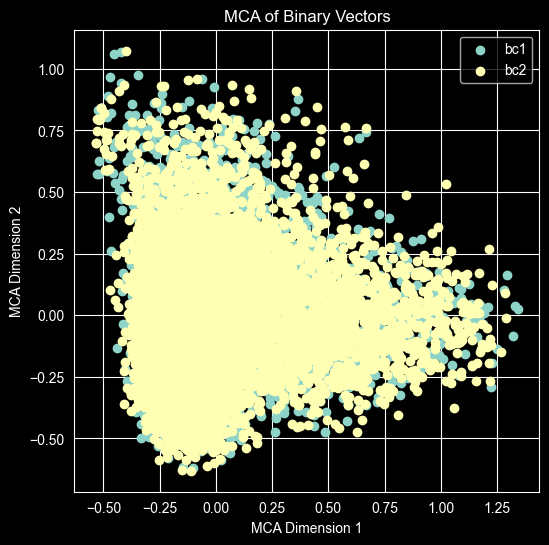

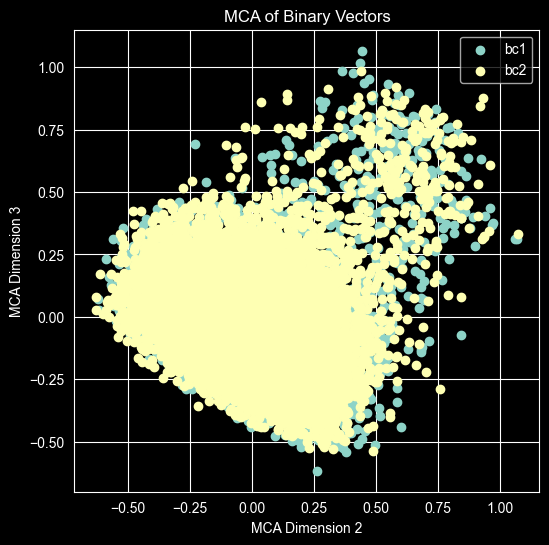

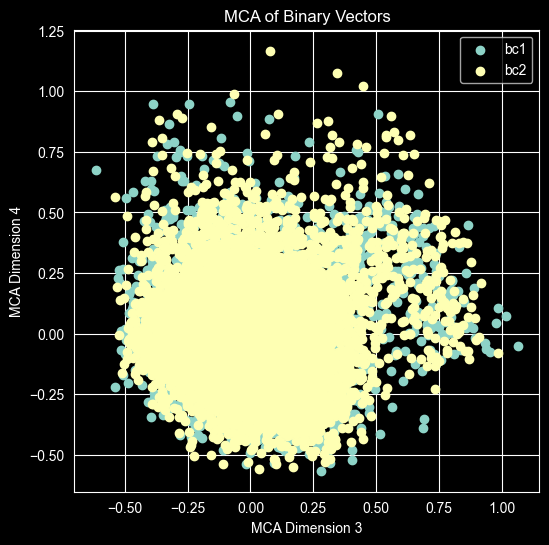

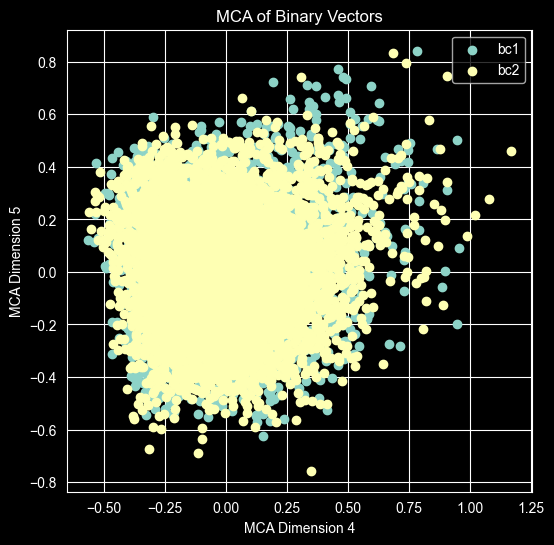

                  0         1         2         3         4
A60__0.0   0.008392  0.000944  0.000097  0.028408  0.004309
A60__1.0   0.071559  0.007584  0.001065  0.235129  0.023827
A61__0.0   0.014230  0.001848  0.000067  0.044299  0.007458
A61__1.0   0.152734  0.016723  0.000314  0.453581  0.065004
A62__0.0   0.024867  0.000841  0.001273  0.053429  0.013392
...             ...       ...       ...       ...       ...
A117__1.0  0.005566  0.260228  0.131802  0.049976  0.453674
A118__0.0  0.011403  0.398762  0.191907  0.079106  0.527580
A118__1.0  0.008762  0.293296  0.140416  0.057181  0.388135
A119__0.0  0.010559  0.439172  0.221531  0.062335  0.738434
A119__1.0  0.003775  0.151948  0.076258  0.021647  0.255940

[120 rows x 5 columns]


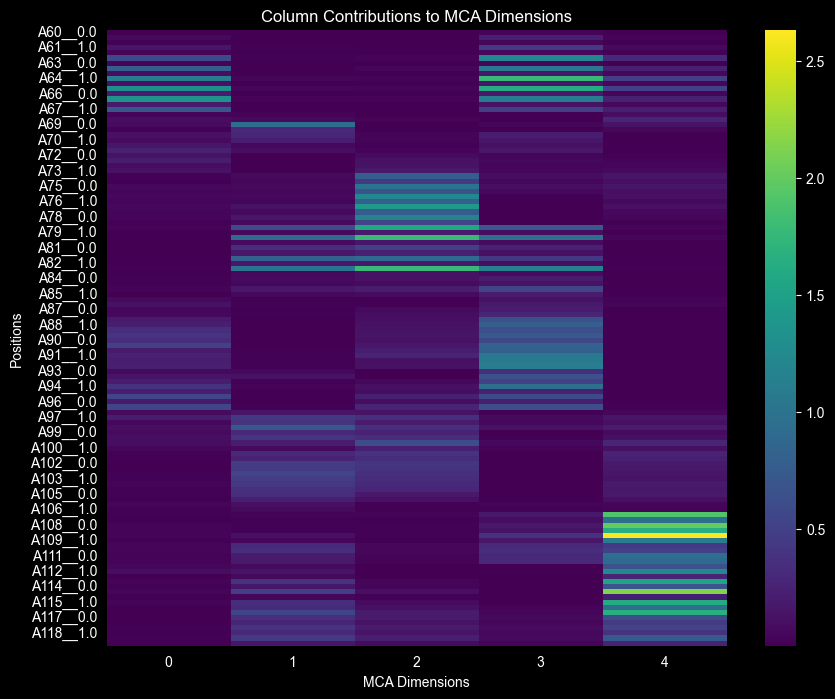

In [70]:
X_mca = doMCAandPlot(matrixOfEdits,listOfBCs,listOfReadIDs,outPrefix / '251205_MCA')

In [6]:
X_mca

,0,1,2,3,4,label,readID
0,-0.041182,0.099304,-0.032155,-0.252539,0.211763,bc1,ef945db2-4afc-4d6b-8344-66c247f24192
1,0.045718,-0.014478,-0.095434,0.109552,-0.088706,bc1,545b767d-127c-496d-8c75-37410b8117eb
2,-0.222866,-0.226259,0.148743,0.002406,0.231189,bc1,80e684b9-9e90-4224-9e99-91d4991e8f2e
3,-0.075379,-0.052469,-0.191378,0.023105,0.046993,bc1,ca7cbc77-16ae-4134-9fd2-e5d8e6fbe3b8
4,0.068425,0.573968,0.856103,0.022129,-0.148656,bc1,0c55248c-99c2-466d-990c-94d5c7af6d80
...,...,...,...,...,...,...,...
14316,0.107787,-0.036877,0.147355,-0.228444,-0.074136,bc2,5453e712-20e6-434b-81c0-f0377e4d5eb6
14317,0.355017,0.123012,-0.165870,0.117761,-0.020603,bc2,0a65c825-58b1-493b-9984-650ad6823f18
14318,-0.137033,0.351673,-0.171792,0.216179,0.169188,bc2,8850caac-8bd8-4b22-b5a3-2f103422ef53
14319,-0.114834,-0.404663,0.164130,-0.098206,-0.032904,bc2,71ac0370-e171-4897-aff1-121bdbc1b0d0


In [7]:
# get reads where dimension 2 is > 0.5
filtered_reads = X_mca[X_mca[2] > 0.5]
filtered_reads

,0,1,2,3,4,label,readID
4,0.068425,0.573968,0.856103,0.022129,-0.148656,bc1,0c55248c-99c2-466d-990c-94d5c7af6d80
80,-0.035309,0.294939,0.859289,0.251524,0.143085,bc1,d34f9165-8b36-4917-bf82-8c04ba729d01
81,-0.191608,0.326885,0.589521,0.320687,0.000015,bc1,4b45308e-9a86-432f-baf6-2dbb6ccd770f
106,0.108552,0.426939,0.797682,0.067256,-0.157354,bc1,13927c87-89c9-410c-a8a0-06041318ec06
162,-0.082606,0.072205,0.649431,0.007529,0.331976,bc1,89ba280f-ff02-49f6-85ca-1442a8124e03
...,...,...,...,...,...,...,...
14210,-0.474741,0.593705,0.612498,0.416362,0.077103,bc2,374b7e7a-2057-4a42-8463-17da5e647ed5
14221,0.616002,0.139425,0.502909,0.024552,-0.075666,bc2,61ce01a4-116a-4a7a-9110-5fb0779cf761
14231,-0.023029,0.621958,0.676303,0.187626,0.340993,bc2,132669b6-0168-4c0a-ac74-592711fefbb5
14289,0.468464,0.755363,0.735227,0.319492,-0.219316,bc2,05c8f8bf-7688-4642-8d5a-f0edc142bd40


In [10]:
dim3_reads = filtered_reads['readID'].to_list()
# write dim3 reads ids to txt
with open(outPrefix / 'dim3_readIDs.txt', 'w') as out:
    for read in dim3_reads:
        out.write(read)
        out.write('\n')

In [14]:
# write to new bam file
import os
input_bam = '/data16/liam/working/data/alignments/251030_JANP-132_LT/demultiplexed_bams_dist0/merged_barcodes.bam'
output_bam = '/data16/liam/working/data/alignments/251030_JANP-132_LT/demultiplexed_bams_dist0/dim3_reads.bam'
os.system(f'samtools view -h -N {outPrefix / "dim3_readIDs.txt"} {input_bam} -o {output_bam}')

0

In [25]:
# sort and index the new bam file
sorted_bam = output_bam.replace('.bam', '.sorted.bam')
os.system(f'samtools sort {output_bam} -o {sorted_bam}')
os.system(f'samtools index {sorted_bam}')

0

In [20]:
# subset read_dict to only include dim3 reads
dim3_read_dict = {}
for bc, read_dicts in read_dict.items():
    for readID, positDict in read_dicts.items():
        if readID in dim3_reads:
            if bc not in dim3_read_dict:
                dim3_read_dict[bc] = {}
            dim3_read_dict[bc][readID] = positDict

In [23]:
dim3_matrixOfEdits,dim3_listOfBCs,dim3_listOfReadIDs = formatForMCA(dim3_read_dict,100,0.35,0.4)

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.005        26.26%                     26.26%
1              0.005        24.81%                     51.06%
2              0.002        11.94%                     63.00%
3              0.002         8.66%                     71.66%
4              0.001         5.83%                     77.49%
                  0         1         2         3         4
A60__0     0.001343 -0.039985  0.000693 -0.120570 -0.112928
A60__1    -0.013660  0.265901  0.002217  0.769892  0.724232
A61__0    -0.015292  0.034982 -0.054315 -0.171527 -0.032987
A61__1     0.097087 -0.224038  0.370405  1.145164  0.221443
A62__0.0   0.015984  0.010069 -0.012065 -0.057370 -0.000585
...             ...       ...       ...       ...       ...
A117__1.0 -0.223928 -0.107419  0.183075 -0.013427  0.282246
A118__0    0.185788  0.194250 -0.141494  0.137141 -0.410853
A118__1   -0.130263 -0.132

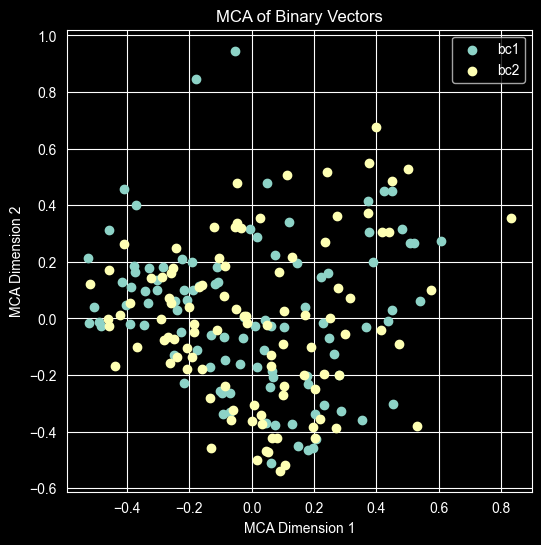

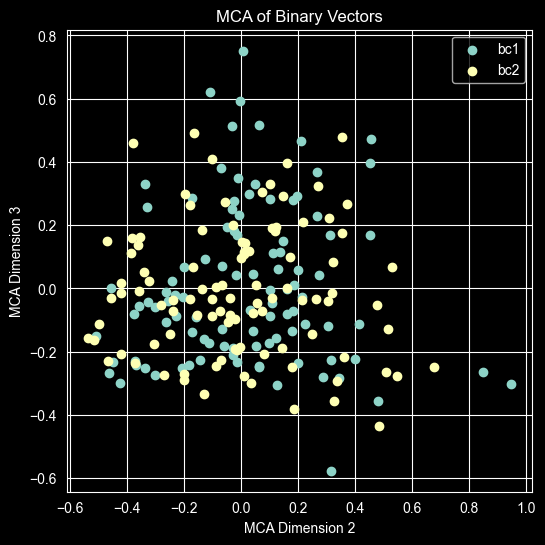

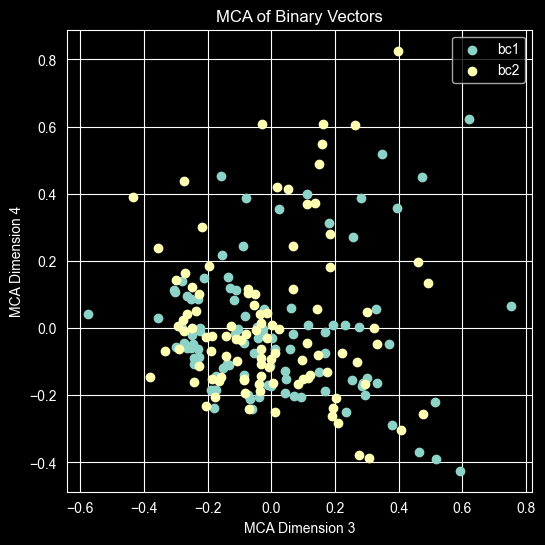

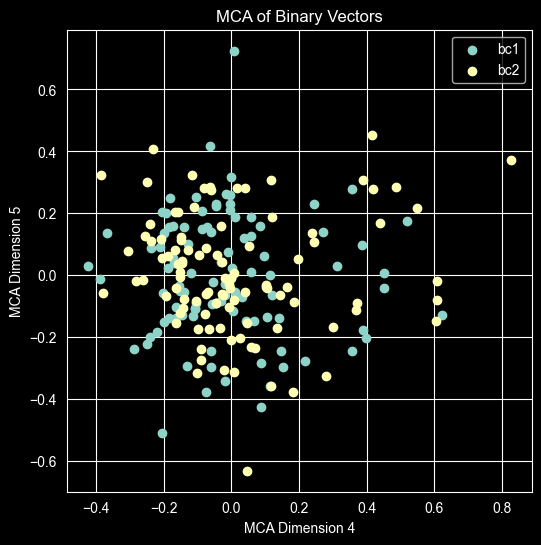

                  0         1         2         3         4
A60__0     0.000005  0.004683  0.000003  0.121973  0.158991
A60__1     0.000081  0.032324  0.000005  0.776187  1.020575
A61__0     0.000651  0.003606  0.018065  0.248289  0.013645
A61__1     0.003921  0.022097  0.125542  1.653680  0.091881
A62__0.0   0.000785  0.000330  0.000984  0.030649  0.000005
...             ...       ...       ...       ...       ...
A117__1.0  0.094663  0.023055  0.139189  0.001032  0.677428
A118__0    0.045282  0.052391  0.057777  0.074798  0.997498
A118__1    0.032034  0.035220  0.041404  0.052641  0.693908
A119__0    0.029816  0.276480  0.092020  0.042324  0.791691
A119__1    0.008665  0.076465  0.026832  0.012214  0.223659

[120 rows x 5 columns]


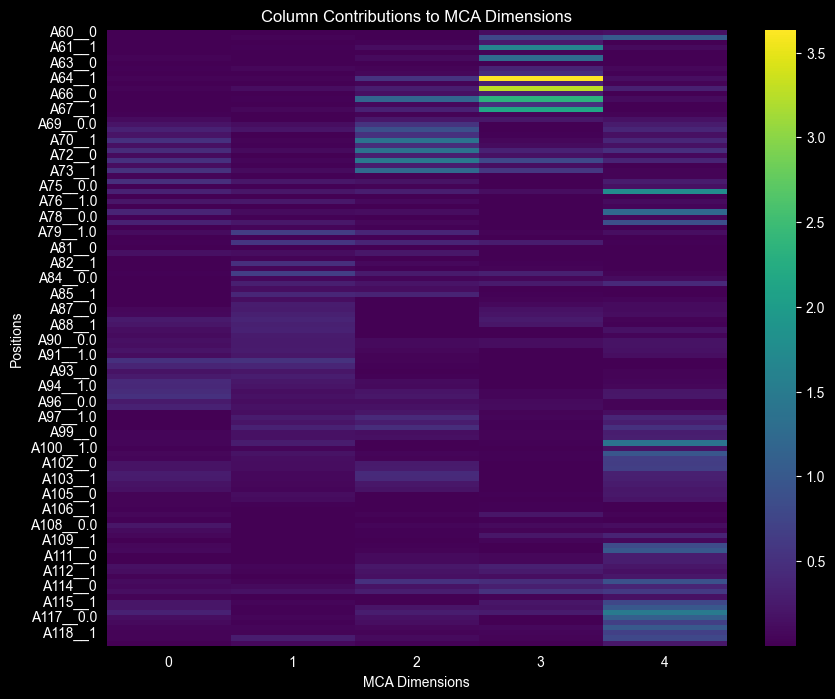

In [24]:
# run MCA and plot, don't recluster on lysine window this time!!
dim3_X_mca = doMCAandPlot(dim3_matrixOfEdits,dim3_listOfBCs,dim3_listOfReadIDs,outPrefix / '251205_MCA_dim3_only')

In [32]:
def binReadsByShadow(read_dict, lysineCoords, outPrefix):
    '''
    This function will bin reads from read_dict according to whether they have an edit within the shadow regions
    defined by lysineCoords. It will output a barchart of the fraction of reads with shadows vs. without shadows for each barcode.
    read_dict: {bc:{readID:{position:1/0}}}
    coords: list of tuples of (start, end) positions to define shadow regions
    outPrefix: output prefix for plot
    '''
    shadow_bins = collections.defaultdict(lambda: {'with_shadow': 0, 'without_shadow': 0})
    for bc, readDict in read_dict.items():
        for readID, positDict in readDict.items():
            has_shadow = True
            for pos in positDict:
                for (start, end) in lysineCoords:
                    if pos >= start and pos <= end and positDict[pos] == 1:
                        has_shadow = False
                        break
                if not has_shadow:
                    break
            if has_shadow:
                shadow_bins[bc]['with_shadow'] += 1
            else:
                shadow_bins[bc]['without_shadow'] += 1
    # prepare data for plotting
    barcodes = []
    with_shadow = []
    without_shadow = []
    for bc, counts in shadow_bins.items():
        total = counts['with_shadow'] + counts['without_shadow']
        barcodes.append(bc)
        with_shadow.append(counts['with_shadow'] / total if total > 0 else 0)
        without_shadow.append(counts['without_shadow'] / total if total > 0 else 0)
    # plot barchart
    x = numpy.arange(len(barcodes))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x, with_shadow, width, label='With Shadow')
    # bars2 = ax.bar(x + width/2, without_shadow, width, label='Without Shadow')
    ax.set_ylabel('Fraction of Reads')
    ax.set_title('Fraction of Reads With/Without Shadows by Barcode')
    ax.set_xticks(x)
    ax.set_xticklabels(barcodes, rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{outPrefix}_shadow_barchart.png", dpi=300)
    plt.close()

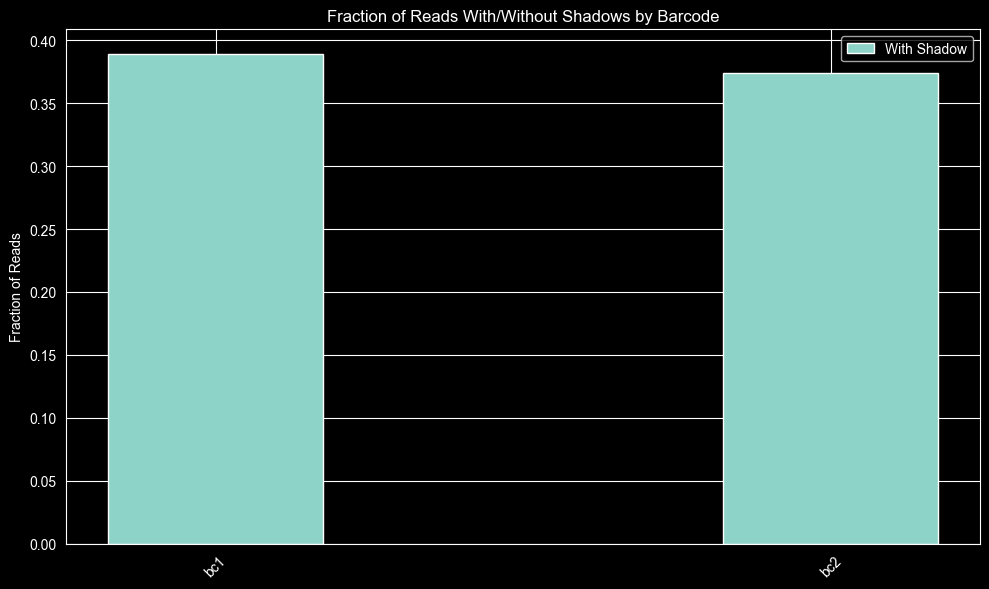

In [37]:
binReadsByShadow(dim3_read_dict, [(255, 285)], outPrefix / '251219_shadow_analysis')

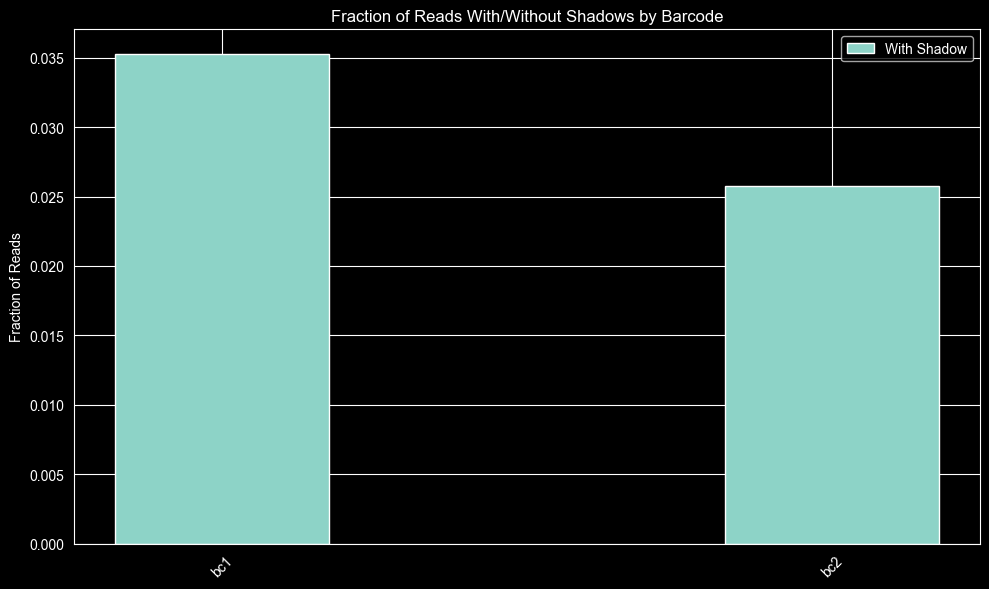

In [41]:
binReadsByShadow(read_dict, [(255, 285)], outPrefix / '251219_shadow_analysis_allReads')


## Let's tighten the window to cluster on lysines even more

In [61]:
def parsePickleFile(pickleFile, barcodeDict=None):
    """
    dataDict is of format:
    {readID:{edit_string,barcode,query_string,ref_string,aligned_pairs:...}}
    Will sort reads according to barcode, and output a tally of the number
    of reads per barcode. Will also compute the total size (in nts) of each
    barcode, to get a sense of coverage.

    Will output a dictionary of format:
    {bc:{readID:{position:edit}}}
    """
    ##start by unpickling the input file
    with open(pickleFile,'rb') as f:
        dataDict=pickle.load(f)
    ##
    aa=collections.defaultdict(lambda:collections.defaultdict(int))
    for readID,subDict in dataDict.items():
        bc=subDict['barcode']
        if barcodeDict is not None:
            if bc not in barcodeDict:
                continue
        queryLength=len(subDict['read_sequence'])
        aa[bc]['ct']+=1
        aa[bc]['length']+=queryLength
    ##
    for k,v in aa.items():
        print('Barcode %s had %s sequences totaling %s kilo nts.'%(\
            k,v['ct'],v['length']/1000))
    ##
    bb=collections.defaultdict(lambda:collections.defaultdict(dict))
    ##
    for readID,subDict in dataDict.items():
        barCode=subDict['barcode']
        #print(barCode,readID)
        editString=subDict['edit_string']
        #print(editString,len(editString))
        readSeq=subDict['read_sequence_aligned']
        #print(readSeq,len(readSeq))
        refSeq=subDict['ref_sequence_aligned']
        #print(refSeq,len(refSeq))
        alignedPairs=subDict['aligned_pairs']
        #print(alignedPairs,len(alignedPairs))
        #sys.exit()
        if barcodeDict is not None:
            if barCode not in barcodeDict:
                continue
        for ii in range(len(alignedPairs)-1):
            entry=alignedPairs[ii]
            idx=entry[0]
            absIdx=entry[1]
            if idx!=None and absIdx!=None:
                seq=refSeq[ii]
                edit=editString[ii]
                if seq=='A' and edit!='2' and absIdx<=704:
                    ##695 is where the RT primer binds--anything past this
                    ##is artifact.
                    bb[barCode][readID][absIdx]=int(edit)
    ##
    return bb

def parseBarcodeFile(barcodeFile):
    '''
    Given a barcode txt file, will return a dict of
    {barcode:library_name}
    '''
    bcDict={}
    with open(barcodeFile,'r') as f:
        for line in f:
            line=line.rstrip()
            print(line)
            if line=='':
                continue
            parts=line.split(',')
            bc=parts[0]
            libName=parts[1]
            bcDict[bc]=libName
    ##
    return bcDict

def formatForMCA(dataDict,numReads,minEditFreq,maxEditFreq):
    """
    dataDict={bc:{readID:{position:1/0}}}
    numReads is an integer.
    minEditFreq is a frequency (e.g., 0.7)
    maxEditFreq is a frequency (e.g., 1.0)
    Will sort each bc's readIDs by longest -> shortest, and then select the
    numReads longest reads with at least minEditFreq of 1's
    Will then convert to a list-of-lists like:
    [[0,1,1,0,...,1],
     [1,1,0,1,...,1],
     ...
     [1,0,0,0,...,0]]
     where each row represents a different readID. Will also return a list
     of bcs, which are the row labels.
    """
    aa=[]
    ##This part just gets the numReads reads from each bc
    for bc,readDict in dataDict.items():
        temp=[]
        for readID,positDict in readDict.items():
            if sum(positDict.values())/len(positDict)>=minEditFreq and \
               sum(positDict.values())/len(positDict)<=maxEditFreq:
                temp.append(len(positDict))
        ##
        temp.sort()
        temp.reverse()
        ##
        temp2=[]
        for readID,positDict in readDict.items():
            if len(positDict) in temp[:numReads]:
                if sum(positDict.values())/len(positDict)>=minEditFreq:
                    # temp2.append((bc,positDict))
                    temp2.append((bc,readID,positDict))
            if len(temp2)==numReads:
                break
        ##
        aa+=temp2
    ##
    ##now get all the positions
    positions=[]
    for entry in aa:
        for k in entry[2]: ##entry[2] is the positDict
            positions.append(k)
    ##now get unique positions, and then sort them
    positions=list(set(positions))
    positions.sort()
    ##now prepare outputs
    matrixOfEdits=[]
    listOfBCs=[]
    listOfReadIDs=[]
    for entry in aa:
        ##record the bc
        listOfBCs.append(entry[0])
        ##record the readID
        listOfReadIDs.append(entry[1])
        ##now convert the dict to a vector/list
        temp=[]
        for k in positions:
            # cluster on lysine window [255, 285]
            if k in entry[2]: ##entry[2] is the positDict
                if k >= 220 and k <= 380:
                    v=entry[2][k]
                else:
                    v=numpy.nan##in case no value
            else:
                v=numpy.nan##in case no value

            temp.append(v)
        ##
        matrixOfEdits.append(temp)
    ##
    return matrixOfEdits,listOfBCs,listOfReadIDs

def doMCAandPlot(matrixOfEdits,listOfBCs,listOfReadIDs,outPrefix):
    """
    matrixOfEdits is a list of lists, where each list is a list of 1/0/nan
    indicated edit status. listOfBCs are the labels associated with that.
    Will run MCA and plot the first two components.
    """
    ##convert to DF
    X = pd.DataFrame(matrixOfEdits,\
        columns=['A%s'%(ii) for ii in range(len(matrixOfEdits[0]))])
    ##initialize mca
    mca = prince.MCA(n_components=5, n_iter=5, \
        copy=True, check_input=True, engine='sklearn', \
        random_state=42, correction="greenacre")
    ##
    mca_fit = mca.fit(X)
    X_mca = mca_fit.transform(X)
    ##create labels, but don't actually attached them to the DF
    labels = pd.Series(listOfBCs, name='label')
    readID_labels = pd.Series(listOfReadIDs, name='readID')
    ##add the labels
    X_mca['label'] = labels.values
    X_mca['readID'] = readID_labels.values
    ##print some results
    print(mca.eigenvalues_summary)
    print(mca.column_coordinates(X))
    ##
    for ii in range(4):
        ##plot the data
        fig, ax = plt.subplots(figsize=(6, 6))
        for label in X_mca['label'].unique():
            subset = X_mca[X_mca['label'] == label]
            ax.scatter(subset[ii], subset[ii+1], label=label)
        ##set axis labels
        ax.set_title('MCA of Binary Vectors')
        ax.set_xlabel('MCA Dimension %s'%(ii+1))##+1 b/c python 0-based
        ax.set_ylabel('MCA Dimension %s'%(ii+2))
        ax.legend()
        ##save output
        plt.savefig('%s.%s.%s.png'%(outPrefix,ii,ii+1))
        plt.show()
        plt.close()
    # plot heatmap of column contributions
    contributions = mca.column_contributions_
    print(contributions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(contributions, cmap='viridis')
    plt.title('Column Contributions to MCA Dimensions')
    plt.xlabel('MCA Dimensions')
    plt.ylabel('Positions')
    plt.savefig(f"{outPrefix}_mca_column_contributions_heatmap.png", dpi=300)
    plt.show()
    plt.close()
    return X_mca

In [48]:
read_dict = parsePickleFile(pickle_path, barcodeDict=barcodeDict)

Barcode bc1 had 8051 sequences totaling 5881.605 kilo nts.
Barcode bc2 had 13977 sequences totaling 10231.988 kilo nts.


In [59]:
matrixOfEdits,listOfBCs,listOfReadIDs = formatForMCA(read_dict,20000,0.35,0.4)

In [63]:
# run MCA and plot
X_mca = doMCAandPlot(matrixOfEdits,listOfBCs,listOfReadIDs,outPrefix / '251219_MCA_tightened_window')

/home/liam/.local/lib/python3.11/site-packages/prince/ca.py:84: RuntimeWarning: divide by zero encountered in power
  S = sparse.diags(r**-0.5) @ (X - np.outer(r, c)) @ sparse.diags(c**-0.5)


ValueError: Input contains NaN.